# Salient Object Detection - Live Demo

In [91]:
import time
import tkinter as tk
from tkinter import filedialog
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import torchvision.transforms.functional as TF

from sod_model import build_model

print('All imports successful')

All imports successful


In [92]:
MODEL_PATH = 'runs/improved/best_model.pth'
IMAGE_SIZE = 128
VARIANT    = 'improved'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = build_model(VARIANT, input_size=IMAGE_SIZE).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

print(f'Model loaded  |  device = {DEVICE}')

[build_model] IMPROVED  |  params = 31,037,633
Model loaded  |  device = cpu


In [93]:
root = tk.Tk()
root.withdraw()          
root.wm_attributes('-topmost', True)  

img_path = filedialog.askopenfilename(
    title='Select an image',
    initialdir='data/ECSSD/images',
    filetypes=[('Image files', '*.jpg *.jpeg *.png *.bmp')]
)
root.destroy()

if not img_path:
    raise RuntimeError('No image selected. Please run again and select an image.')

print(f'Selected: {Path(img_path).name}')

Selected: 0014.jpg


In [94]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

pil     = Image.open(img_path).convert('RGB')
resized = TF.resize(pil, [IMAGE_SIZE, IMAGE_SIZE])
t       = (TF.to_tensor(resized) - MEAN) / STD

t0 = time.perf_counter()
with torch.no_grad():
    pred = model(t.unsqueeze(0).to(DEVICE)).cpu().squeeze().numpy()
ms = (time.perf_counter() - t0) * 1000

print(f'Inference done  |  time = {ms:.1f} ms')

Inference done  |  time = 95.1 ms


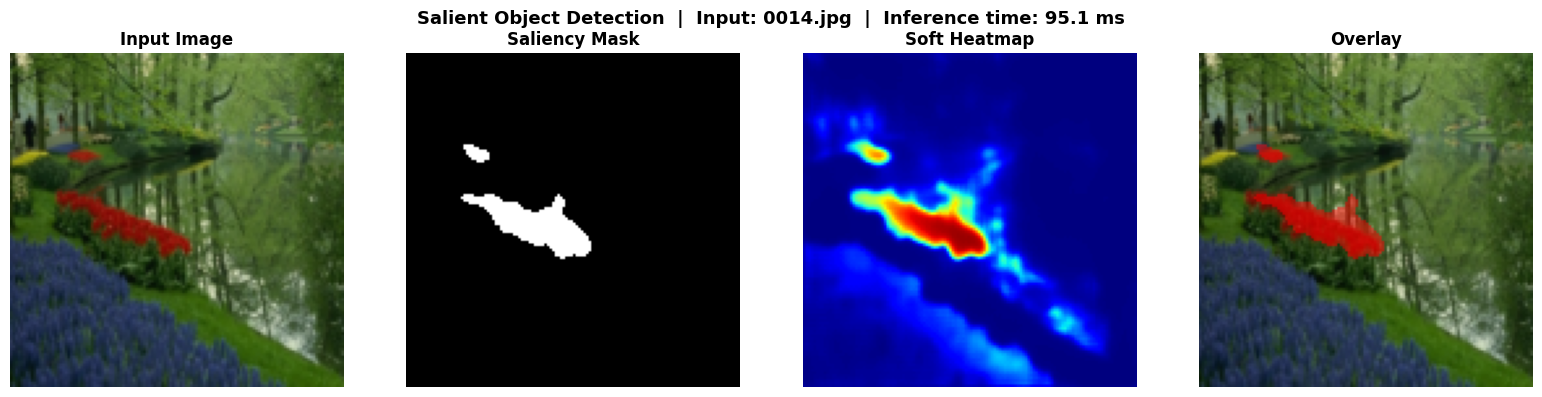

In [95]:
img_np  = np.array(resized)
binary  = (pred > 0.5).astype(np.float32)
heat    = (cm.jet(pred)[:, :, :3] * 255).astype(np.uint8)
alpha   = 0.5
overlay = (img_np * (1 - alpha * binary[..., None]) +
           np.array([255, 0, 0]) * alpha * binary[..., None]).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(
    f'Salient Object Detection  |  Input: {Path(img_path).name}  |  Inference time: {ms:.1f} ms',
    fontsize=13, fontweight='bold'
)

panels = [
    (img_np,  'Input Image',   None),
    (binary,  'Saliency Mask', 'gray'),
    (heat,    'Soft Heatmap',  None),
    (overlay, 'Overlay',       None),
]

for ax, (data, title, cmap) in zip(axes, panels):
    ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()